In [3]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from scipy import stats
from IPython.display import Markdown

base_df = pd.read_csv('../data/spotify_churn_dataset.csv')


In [4]:
np.random.seed(97)

# base_df["treatment_group"] = None

base_df["treatment_group"] = (
    base_df
    .groupby("subscription_type")["subscription_type"]
    .transform(lambda x: np.random.choice(
        ["Control", "Treatment"],
        size=len(x),
        p=[0.7, 0.3]
    ))
)

## Overview

We evaluate a hypothetical product change aimed at increasing user engagement on the platform.

We conduct an A/B test to determine whether the treatment has a meaningful impact on listening time.

- Primary metric: Listening time per user

# Exploratory Data Analysis

## Dataset Overview

::: columns

::: {.column width="40%"}


In [5]:
rows, cols = base_df.shape

display(Markdown(f"""

- Contains **{rows:,} users** and **{cols} features**

- Time window is not explicitly documented in the source dataset

- Presence of weekly aggregated variables suggests a short-term behavioral snapshot, but exact duration is unknown
"""))



- Contains **8,000 users** and **13 features**

- Time window is not explicitly documented in the source dataset

- Presence of weekly aggregated variables suggests a short-term behavioral snapshot, but exact duration is unknown


:::

::: {.column width="60%"}

In [6]:
col_info = pd.DataFrame({
    "Column": [
        "user_id",
        "gender",
        "age",
        "country",
        "subscription_type",
        "listening_time",
        "songs_played_per_day",
        "skip_rate",
        "device_type",
        "ads_listened_per_week",
        "offline_listening",
        "is_churned",
        "treatment_group"
    ],
    "Description": [
        "Unique user identifier",
        "User gender",
        "Age of user",
        "Country of user",
        "Free / Premium subscription",
        "Total listening time",
        "Avg songs played per day",
        "Fraction of songs skipped",
        "Device used (mobile/desktop/etc.)",
        "Ads listened per week (Free users)",
        "Whether user uses offline mode",
        "Whether user churned",
        "A/B test assignment (control,treatment)"
    ],
    "Type": [
        "ID",
        "Categorical",
        "Numeric",
        "Categorical",
        "Categorical",
        "Numeric",
        "Numeric",
        "Numeric",
        "Categorical",
        "Numeric",
        "Binary",
        "Binary",
        "Categorical"
    ]
})

(col_info
 .style
 .hide(axis="index")
 .set_caption("Dataset features overview")
)


Column,Description,Type
user_id,Unique user identifier,ID
gender,User gender,Categorical
age,Age of user,Numeric
country,Country of user,Categorical
subscription_type,Free / Premium subscription,Categorical
listening_time,Total listening time,Numeric
songs_played_per_day,Avg songs played per day,Numeric
skip_rate,Fraction of songs skipped,Numeric
device_type,Device used (mobile/desktop/etc.),Categorical
ads_listened_per_week,Ads listened per week (Free users),Numeric


:::

:::

## Experiment Design

We simulate an A/B test, evaluating the impact of an improved recommendation system on user engagement and churn.

::: columns

::: column

- Stratified randomization by subscription type
- 70/30 treatment-control split within each group
- Ensures balanced representation across subscription types
- Allows us to estimate treatment effects both overall and within subscription segments

:::

::: column

- Control: existing recommendation system  
- Treatment: improved personalization experience  
- Unit of randomization: user-level  

:::

:::

## Randomization Check

We compare pre-treatment characteristics across control and treatment groups to validate the random assignment.

Looking at the most important characteristics, subscription and device type, we see no meaningful differens between control and treatment groups.

<br><br>

::: columns

::: column

In [7]:
cat_cols = [
    "subscription_type",
    "country",
    "device_type",
    "gender"
]

cat_tables = {}

for col in cat_cols:
    cat_tables[col] = (
        pd.crosstab(
            base_df[col],
            base_df["treatment_group"],
            normalize="columns"
        )
    )

(cat_tables["subscription_type"]
 .mul(100)
 .round(1)
 .sort_index()
 .style
 .format("{:.1f}%")
 .set_caption("Subscription Type Distribution by Treatment Group")
)

treatment_group,Control,Treatment
subscription_type,,
Family,23.6%,24.4%
Free,24.9%,25.9%
Premium,26.7%,25.8%
Student,24.7%,23.9%


:::

::: column

In [8]:

(cat_tables["device_type"]
 .mul(100)
 .round(1)
 .sort_index()
 .style
 .format("{:.1f}%")
 .set_caption("Device Type Distribution by Treatment Group")
)

treatment_group,Control,Treatment
device_type,,
Desktop,34.7%,34.7%
Mobile,32.6%,32.3%
Web,32.7%,33.0%


:::

:::

## Impact on Listening Time

::: columns

::: {.column width="40%"}

### Key Results

- The treatment had a slightly negative impact on listening time
- Very similar distributions of listening time between the groups

:::

::: {.column width="60%"}

In [9]:
metrics = (
    base_df
    .groupby("treatment_group")["listening_time"]
    .agg(["mean", "std", "count"])
)

control_mean = metrics.loc['Control', "mean"]
treatment_mean = metrics.loc['Treatment', "mean"]

lift = treatment_mean - control_mean
lift_pct = (lift / control_mean) * 100

display_table = pd.DataFrame({
    "Metric": ["Listening Time"],
    "Control": [control_mean],
    "Treatment": [treatment_mean],
    "Relative Lift": [lift_pct]
}).round(1)

(display_table
 .style
 .hide(axis="index")
 .format({
     "Control": "{:.1f}",
     "Treatment": "{:.1f}",
     "Relative Lift": "{:.1f}%"
 })
 .set_caption("Impact on Listening Time")
)

Metric,Control,Treatment,Relative Lift
Listening Time,155.1,151.8,-2.1%


<br><br>

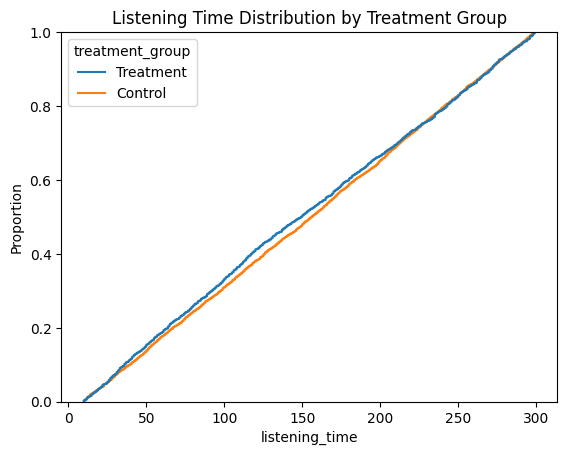

In [10]:

sns.ecdfplot(
    data=base_df,
    x="listening_time",
    hue="treatment_group"
)

plt.title("Listening Time Distribution by Treatment Group")
plt.show()

:::

:::

## Statistical Significance (Welch’s t-test)

We test whether the observed difference in listening time between groups is statistically significant.

::: columns

::: {.column width="55%"}

### Why Welch’s t-test?

- Treatment and control groups are **unequal in size (70/30 split)**
- Variance between groups may differ
- Welch’s t-test does **not assume equal variances**
- Robust choice for real-world A/B tests
- Two-sided test is used as we do not assume a directional effect

### Hypotheses

- Null hypothesis: no difference in mean listening time  
- Alternative hypothesis: difference exists  

### Result

- The test is **not statistically significant (p > 0.05)**  
- We fail to reject the null hypothesis  

### Interpretation

- No strong evidence that the treatment changes listening time  
- Observed decrease in listening time may be due to random variation  
:::

::: {.column width="45%"}

<br><br>

In [11]:


control = base_df[base_df["treatment_group"] == "Control"]["listening_time"]
treatment = base_df[base_df["treatment_group"] == "Treatment"]["listening_time"]

t_stat, p_val = stats.ttest_ind(
    treatment,
    control,
    equal_var=False
)

results = pd.DataFrame({
    "t-statistic": [t_stat],
    "p-value": [p_val]
}).round(2)

(results.style
 .hide(axis="index")
 .format("{:.2f}").set_caption("Welch’s t-test comparing mean listening time between Control and Treatment groups"))


t-statistic,p-value
-1.59,0.11


:::

:::

## Effect Size Interpretation (Listening Time)

We estimate a small negative change in listening time for the treatment group compared to control.

::: columns

::: {.column width="55%"}

### Key Findings

- Treatment shows a **small decrease in listening time**
- Effect size is **negative but small in magnitude**
- Difference is **not statistically significant (p > 0.05)**

### Interpretation

- No strong evidence of a real impact on engagement
- Observed difference is likely due to random variation
- Effect is too small to draw product conclusions

:::

::: {.column width="45%"}

### Summary Metrics


In [12]:
(display_table
 .style
 .hide(axis="index")
 .format({
     "Control": "{:.1f}",
     "Treatment": "{:.1f}",
     "Relative Lift": "{:.1f}%"
 })
 .set_caption("Impact on Listening Time")
)

Metric,Control,Treatment,Relative Lift
Listening Time,155.1,151.8,-2.1%


<br><br>

In [13]:
(results.style
 .hide(axis="index")
 .format("{:.2f}").set_caption("Welch’s t-test comparing mean listening time between Control and Treatment groups"))


t-statistic,p-value
-1.59,0.11


:::

:::

## Segmented Effects Based on Subscription Type (Listening Time)

::: columns

::: {.column width="55%"}

We examine whether the treatment effect varies across subscription types.


### Key Findings

- We observe variation in treatment response across subscription segments
- Overall effects remain small in magnitude (≈ -5% to +3%)
- No consistent directional pattern across all groups
- Small positive change for Students (+2.6%)

:::

::: {.column width="45%"}

### Subscription Type Breakdown


In [14]:
means = (
    base_df
    .groupby(["subscription_type", "treatment_group"])["listening_time"]
    .mean()
    .unstack()
)

(means
 .assign(**{
     "Relative Lift": lambda x: ((x["Treatment"] - x["Control"]) / x["Control"] * 100)
 })
 .round(1)
 .sort_values("Relative Lift")
 .style
 .format({
     "Control": "{:.1f}",
     "Treatment": "{:.1f}",
     "Relative Lift": "{:.1f}%"
 })
 .set_caption("Mean listening time by subscription type with lift vs Control (Treatment − Control) / Control"))

treatment_group,Control,Treatment,Relative Lift
subscription_type,,,
Family,153.2,146.4,-4.4%
Premium,157.0,152.0,-3.2%
Free,156.5,151.7,-3.1%
Student,153.3,157.2,2.6%


:::

:::

## Segmented Effects by Device Type (Listening Time)

::: columns

::: {.column width="55%"}

We examine whether the treatment effect varies across device types.

### Key Findings

- Small negative effect observed for **mobile and desktop**
- No meaningful change for web users
- Effects are **consistent in direction across major device types**

### Interpretation

- No device segment shows a positive response to the treatment  
- Slightly negative effects across key platforms suggest lack of product benefit  
- Results reinforce the overall neutral to negative impact observed  

:::

::: {.column width="45%"}

### Device Type Breakdown

In [15]:
means = (
    base_df
    .groupby(["device_type", "treatment_group"])["listening_time"]
    .mean()
    .unstack()
)

(means
 .assign(**{
     "Relative Lift": lambda x: ((x["Treatment"] - x["Control"]) / x["Control"] * 100)
 })
 .round(1)
 .sort_values("Relative Lift")
 .style
 .format({
     "Control": "{:.1f}",
     "Treatment": "{:.1f}",
     "Relative Lift": "{:.1f}%"
 })
 .set_caption("Mean listening time by device type with lift vs Control (Treatment − Control) / Control"))

treatment_group,Control,Treatment,Relative Lift
device_type,,,
Desktop,158.4,151.5,-4.4%
Web,156.5,153.4,-2.0%
Mobile,150.1,150.5,0.3%


:::

:::

## Guardrail Metrics (Treatment Safety Check)

We evaluate whether the treatment negatively impacts retention or engagement quality.

::: columns

::: {.column width="55%"}

### Key results:

- Churn rate: slightly higher in treatment (~+1.9%)
- Skip rate: no meaningful difference between groups
- Engagement metrics remain stable

### Interpretation:

- No strong evidence of degradation in engagement quality
- Slight increase in churn may indicate a potential risk, but is not conclusive
- Results should be interpreted cautiously

:::

::: {.column width="45%"}

In [16]:
guardrails = (
    base_df
    .groupby("treatment_group")[["is_churned", "skip_rate"]]
    .mean()
    .mul(100)
    .round(2)
    .T
    .rename(index={
        "is_churned": "Churn rate",
        "skip_rate": "Skip rate"
    })
)

guardrails["Relative Lift"] = (
    (guardrails["Treatment"] - guardrails["Control"]) / guardrails["Control"] * 100
).round(2)

guardrails.style.format({
    "Control": "{:.1f}%",
    "Treatment": "{:.1f}%",
    "Relative Lift": "{:.1f}%"
}).set_caption("Guardrail metrics (Control vs Treatment with relative lift)")

treatment_group,Control,Treatment,Relative Lift
Churn rate,25.3%,27.2%,7.5%
Skip rate,30.1%,29.9%,-0.5%


:::

:::

# Conclusions & Recommendations

## Executive Summary

- No statistically significant effect on listening time  
- Small negative average effect observed  
- No consistent effects across subscription types or device segments  
- Slight increase in churn, but not conclusive  
- No meaningful change in skip rate  

### Conclusion:

The treatment does not demonstrate a meaningful impact on user engagement.

## Recommendation

Based on the experiment results:

- Primary metric: no statistically significant impact on listening time
- Guardrails: no clear evidence of degradation in customer retention or engagement quality
- Segment analysis: no consistent positive effects across subscription types

### Decision:

- Do not implement the current version of the treatment
- Results do not demonstrate a meaningful improvement in user engagement
- Recommend redesign and re-test

## Limitations & Next Steps


In [17]:
cv = base_df["listening_time"].std() / base_df["listening_time"].mean()

slide_text = f"""
- Moderate variability in listening time (coefficient of variation = {cv:.2f}) reduces ability to detect small effects
- Observed effects are small, making it difficult to distinguish signal from noise  
- Results reflect short-term behavior and may not capture longer-term engagement patterns  
"""


In [18]:

Markdown(slide_text)


- Moderate variability in listening time (coefficient of variation = 0.55) reduces ability to detect small effects
- Observed effects are small, making it difficult to distinguish signal from noise  
- Results reflect short-term behavior and may not capture longer-term engagement patterns  


### Next Steps:

- Iterate on the treatment design to create a stronger user impact  
- Consider increasing sample size or experiment duration in future tests  
- Continue monitoring retention metrics, given the slight increase in churn  

# Appendix

## Additional Randomization Checks

We compare pre-treatment characteristics across control and treatment groups to validate the random assignment.

Looking at the most important characteristics, gender and age, we see no large differens between control and treatment groups.

<br><br>

::: columns

::: column

In [19]:
(cat_tables["gender"]
 .mul(100)
 .round(1)
 .rename(columns={0: "Control", 1: "Treatment"})
 .style
 .format("{:.1f}%")
 .set_caption("Gender Distribution by Treatment Group")
)

treatment_group,Control,Treatment
gender,,
Female,33.4%,32.8%
Male,33.2%,34.7%
Other,33.4%,32.5%


:::

::: column

In [20]:

base_df["age_group"] = pd.cut(
    base_df["age"],
    bins=[0, 18, 25, 35, 50, 100],
    labels=["<18", "18-25", "26-35", "36-50", "50+"]
)

age_cat_table = pd.crosstab(
    base_df["age_group"],
    base_df["treatment_group"],
    normalize="columns"
)

(age_cat_table
 .mul(100)
 .round(1)
 .rename(columns={0: "Control", 1: "Treatment"})
 .sort_index()
 .style
 .format("{:.1f}%")
 .set_caption("Age Distribution by Treatment Group")
)

treatment_group,Control,Treatment
age_group,,
<18,6.9%,6.1%
18-25,16.3%,16.1%
26-35,21.8%,21.7%
36-50,33.9%,35.7%
50+,21.0%,20.4%


:::

:::